In [1]:
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from collections import Counter

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Credit Card

In [2]:
classification_reports = []
classification_report_keys = []

In [3]:
random_state = 42

### Data

In [4]:
# Import credit card datasaet
df = pd.read_csv('C:/Users/caleb/Projects/BU Spring 2026/Module-B-semester-2/Milestone 3 EDA/credit_card_cleaned.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


### Undersampling

In [5]:
X = df.drop(columns='Class')
y = df['Class']
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 284315, 1: 492})
Resampled dataset shape: Counter({0: 492, 1: 492})


### Split Data

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, 
                                                    y_resampled, 
                                                    test_size=0.2, 
                                                    stratify=y_resampled,  # Maintains class distribution
                                                    random_state=random_state
                                                    )

### Baseline Models
#### (No parameter optimization, feature scaling, or cross validation)

#### Linear Regression

In [7]:
model = LogisticRegression()

In [8]:
model.fit(X_train, y_train)

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [9]:
y_pred = model.predict(X_test)

In [10]:
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Baseline Logistic Regression')

              precision    recall  f1-score   support

           0       0.96      0.93      0.94        99
           1       0.93      0.96      0.94        98

    accuracy                           0.94       197
   macro avg       0.94      0.94      0.94       197
weighted avg       0.94      0.94      0.94       197



#### Ridge

In [11]:
from sklearn.linear_model import RidgeClassifier


ridge_model = RidgeClassifier(random_state=random_state)

In [12]:
ridge_model.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,class_weight,None
,solver,'auto'
,positive,False
,random_state,42


In [13]:
y_pred = ridge_model.predict(X_test)

In [14]:
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Baseline Ridge Classifier')


              precision    recall  f1-score   support

           0       0.89      0.99      0.94        99
           1       0.99      0.88      0.93        98

    accuracy                           0.93       197
   macro avg       0.94      0.93      0.93       197
weighted avg       0.94      0.93      0.93       197



#### Lasso

In [15]:
lasso_model = LogisticRegression(penalty='l1', solver='liblinear')

In [16]:
lasso_model.fit(X_train, y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [17]:
y_pred = lasso_model.predict(X_test)

In [18]:
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Baseline L1 (Lasso) Logistic Regression')

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        99
           1       0.95      0.95      0.95        98

    accuracy                           0.95       197
   macro avg       0.95      0.95      0.95       197
weighted avg       0.95      0.95      0.95       197



### Scaling Data

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Parameter Tuning

#### Logistic Regression

In [20]:
# We can only tune the C (float) and Class_weight to tryout balanced. 

In [21]:
# cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)
from sklearn.model_selection import StratifiedKFold


cv = StratifiedKFold(n_splits=5)

In [22]:
def objective(trial):
    c = trial.suggest_float("C", 0.001, 1.0)
    class_weight = trial.suggest_categorical("Class_weight", ['balanced', None])
    
    model = LogisticRegression(
        class_weight=class_weight,
        C=c,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='recall',
        n_jobs=-1,
    )
    recall = scores.mean()
    
    return recall


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

log_reg_unscaled_recall_optuna_results = study.trials_dataframe().sort_values("value", ascending=False)
top_5_log_reg_unscaled_recall_optuna_results = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_log_reg_unscaled_recall_optuna_results)

[I 2026-06-26 21:31:18,382] A new study created in memory with name: no-name-9eafbf05-631c-4c02-a59d-8a0356bb8cac
[I 2026-06-26 21:31:19,753] Trial 0 finished with value: 0.8882505679974034 and parameters: {'C': 0.44430382540320545, 'Class_weight': 'balanced'}. Best is trial 0 with value: 0.8882505679974034.
[I 2026-06-26 21:31:20,800] Trial 1 finished with value: 0.8907822135670237 and parameters: {'C': 0.9269164971211871, 'Class_weight': 'balanced'}. Best is trial 1 with value: 0.8907822135670237.
[I 2026-06-26 21:31:21,849] Trial 2 finished with value: 0.8907822135670237 and parameters: {'C': 0.7097860044115794, 'Class_weight': None}. Best is trial 1 with value: 0.8907822135670237.
[I 2026-06-26 21:31:22,843] Trial 3 finished with value: 0.8907822135670237 and parameters: {'C': 0.9767036786104064, 'Class_weight': None}. Best is trial 1 with value: 0.8907822135670237.
[I 2026-06-26 21:31:22,861] Trial 4 finished with value: 0.8907822135670237 and parameters: {'C': 0.5619132083014132,

,number,value,datetime_start,datetime_complete,duration,params_C,params_Class_weight,state
31,31,0.893314,2026-06-26 21:31:23.183049,2026-06-26 21:31:23.195180,0 days 00:00:00.012131,0.998584,None,COMPLETE
22,22,0.893314,2026-06-26 21:31:23.073923,2026-06-26 21:31:23.086089,0 days 00:00:00.012166,0.987915,None,COMPLETE
27,27,0.893314,2026-06-26 21:31:23.134236,2026-06-26 21:31:23.146709,0 days 00:00:00.012473,0.992270,None,COMPLETE
9,9,0.893314,2026-06-26 21:31:22.916298,2026-06-26 21:31:22.928435,0 days 00:00:00.012137,0.989617,balanced,COMPLETE
24,24,0.893314,2026-06-26 21:31:23.098167,2026-06-26 21:31:23.110301,0 days 00:00:00.012134,0.992042,None,COMPLETE


In [23]:
def objective(trial):
    c = trial.suggest_float("C", 0.001, 1.0)
    class_weight = trial.suggest_categorical("Class_weight", ['balanced', None])
    
    model = LogisticRegression(
        class_weight=class_weight,
        C=c,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='f1',
        n_jobs=-1,
    )
    recall = scores.mean()
    
    return recall


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

log_reg_unscaled_f1_optuna_results = study.trials_dataframe().sort_values("value", ascending=False)
top_5_log_reg_unscaled_f1_optuna_results = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_log_reg_unscaled_f1_optuna_results)

[I 2026-06-26 21:31:24,131] A new study created in memory with name: no-name-0cba4a68-2b7a-4fc5-a109-96dd5977d405
[I 2026-06-26 21:31:24,146] Trial 0 finished with value: 0.9295807643799391 and parameters: {'C': 0.6562054022896878, 'Class_weight': 'balanced'}. Best is trial 0 with value: 0.9295807643799391.
[I 2026-06-26 21:31:24,164] Trial 1 finished with value: 0.9295807643799391 and parameters: {'C': 0.7579458692305069, 'Class_weight': None}. Best is trial 0 with value: 0.9295807643799391.
[I 2026-06-26 21:31:24,176] Trial 2 finished with value: 0.9295807643799391 and parameters: {'C': 0.5358054349633806, 'Class_weight': 'balanced'}. Best is trial 0 with value: 0.9295807643799391.
[I 2026-06-26 21:31:24,187] Trial 3 finished with value: 0.9295807643799391 and parameters: {'C': 0.9517107364768308, 'Class_weight': 'balanced'}. Best is trial 0 with value: 0.9295807643799391.
[I 2026-06-26 21:31:24,199] Trial 4 finished with value: 0.9253432840491556 and parameters: {'C': 0.318302171065

,number,value,datetime_start,datetime_complete,duration,params_C,params_Class_weight,state
32,32,0.930992,2026-06-26 21:31:24.651335,2026-06-26 21:31:24.665365,0 days 00:00:00.014030,0.993043,balanced,COMPLETE
34,34,0.930992,2026-06-26 21:31:24.680376,2026-06-26 21:31:24.702703,0 days 00:00:00.022327,0.999371,balanced,COMPLETE
38,38,0.930992,2026-06-26 21:31:24.762815,2026-06-26 21:31:24.777078,0 days 00:00:00.014263,0.997699,balanced,COMPLETE
36,36,0.930992,2026-06-26 21:31:24.722495,2026-06-26 21:31:24.741031,0 days 00:00:00.018536,0.998400,None,COMPLETE
54,54,0.930992,2026-06-26 21:31:25.041488,2026-06-26 21:31:25.057576,0 days 00:00:00.016088,0.989935,balanced,COMPLETE


##### Tryout best params

In [24]:
log_reg_recall_optimized_model = LogisticRegression(C=0.769946, class_weight='balanced', random_state=random_state)
log_reg_recall_optimized_model.fit(X_train_scaled, y_train)
y_pred = log_reg_recall_optimized_model.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Logistic Regression (Recall Optimized)')

              precision    recall  f1-score   support

           0       0.95      0.98      0.97        99
           1       0.98      0.95      0.96        98

    accuracy                           0.96       197
   macro avg       0.96      0.96      0.96       197
weighted avg       0.96      0.96      0.96       197



In [25]:
log_reg_f1_optimized_model = LogisticRegression(C=0.315005, class_weight='balanced', random_state=random_state)
log_reg_f1_optimized_model.fit(X_train_scaled, y_train)
y_pred = log_reg_f1_optimized_model.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Logistic Regression (F1 Optimized)')

              precision    recall  f1-score   support

           0       0.95      0.98      0.97        99
           1       0.98      0.95      0.96        98

    accuracy                           0.96       197
   macro avg       0.96      0.96      0.96       197
weighted avg       0.96      0.96      0.96       197



[I 2026-06-26 21:31:25,868] A new study created in memory with name: no-name-d8ce097d-614a-4c33-a785-b400a0d5259f
[I 2026-06-26 21:31:25,886] Trial 0 finished with value: 0.8730282375851995 and parameters: {'C': 0.0936231279781999, 'Class_weight': 'balanced'}. Best is trial 0 with value: 0.8730282375851995.
[I 2026-06-26 21:31:25,902] Trial 1 finished with value: 0.8654008438818565 and parameters: {'C': 0.06731066168322558, 'Class_weight': 'balanced'}. Best is trial 0 with value: 0.8730282375851995.
[I 2026-06-26 21:31:25,918] Trial 2 finished with value: 0.8324569944823109 and parameters: {'C': 0.020838836168254046, 'Class_weight': 'balanced'}. Best is trial 0 with value: 0.8730282375851995.
[I 2026-06-26 21:31:25,938] Trial 3 finished with value: 0.8831872768581629 and parameters: {'C': 0.2950806392450931, 'Class_weight': 'balanced'}. Best is trial 3 with value: 0.8831872768581629.
[I 2026-06-26 21:31:25,963] Trial 4 finished with value: 0.845115222330412 and parameters: {'C': 0.0366

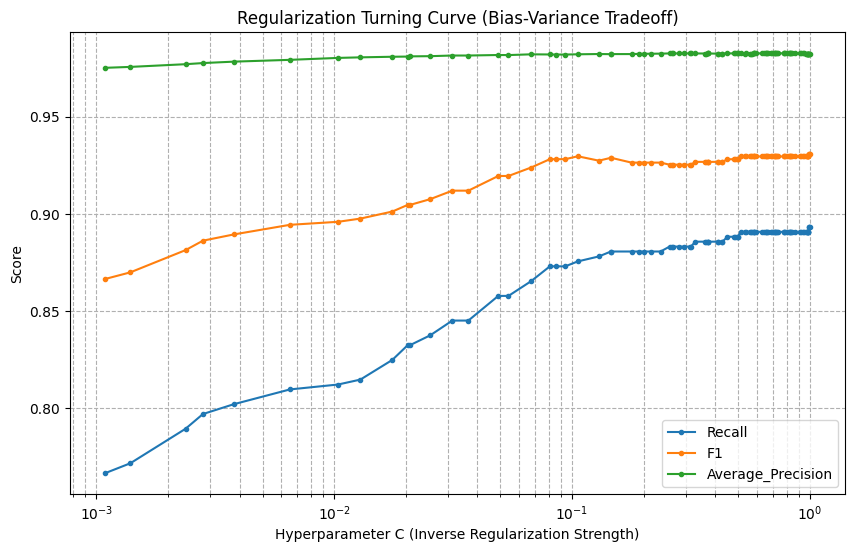

In [26]:
import numpy as np
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, average_precision_score, f1_score

def objective(trial):
    c = trial.suggest_float("C", 0.001, 1.0, log=True) # Log scale is best for regularization
    class_weight = trial.suggest_categorical("Class_weight", ['balanced', None])
    
    model = LogisticRegression(
        class_weight=class_weight, 
        C=c, 
        random_state=random_state,
        max_iter=1000
    )
    
    # Track multiple metrics
    scoring = {
        'recall': 'recall',
        'f1': 'f1',
        'average_precision': 'average_precision'
    }
    
    scores = cross_validate(
        model, X=X_train_scaled, y=y_train, cv=cv, 
        scoring=scoring, n_jobs=-1
    )
    
    # Calculate means across the cross-validation folds
    mean_recall = np.mean(scores['test_recall'])
    mean_f1 = np.mean(scores['test_f1'])
    mean_ap = np.mean(scores['test_average_precision'])
    
    # Store these as trial attributes so you can access them later
    trial.set_user_attr("f1", mean_f1)
    trial.set_user_attr("average_precision", mean_ap)
    
    # Return primary metric (recall, as in your original code)
    return mean_recall

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

import pandas as pd
import matplotlib.pyplot as plt

# Extract C (params) and the user-defined scores from all trials
records = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        records.append({
            "C": t.params["C"],
            "Class_weight": t.params.get("Class_weight"),
            "Recall": t.value,
            "F1": t.user_attrs["f1"],
            "Average_Precision": t.user_attrs["average_precision"]
        })

results_df = pd.DataFrame(records).sort_values("C")

# Plotting the Turning Curve
fig, ax = plt.subplots(figsize=(10, 6))
results_df.plot(x="C", y=["Recall", "F1", "Average_Precision"], ax=ax, style='.-')
ax.set_xscale('log')
ax.set_title("Regularization Turning Curve (Bias-Variance Tradeoff)")
ax.set_xlabel("Hyperparameter C (Inverse Regularization Strength)")
ax.set_ylabel("Score")
plt.grid(True, which="both", ls="--")
plt.show()


#### Ridge

In [27]:
# We can tune alpha and class weight

##### Recall optimized

In [28]:
def objective(trial):
    alpha = trial.suggest_float("alpha", 0.001, 1.0)
    class_weight = trial.suggest_categorical("class_weight", ['balanced', None])
    
    model = RidgeClassifier(
        class_weight=class_weight,
        alpha=alpha,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='recall',
        n_jobs=-1,
    )
    recall = scores.mean()
    
    return recall


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

ridge_unscaled_recall_optuna_results = study.trials_dataframe().sort_values("value", ascending=False)
top_5_ridge_unscaled_recall_optuna_results = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_ridge_unscaled_recall_optuna_results)

[I 2026-06-26 21:31:28,365] A new study created in memory with name: no-name-d6c0ba13-d651-4da8-a3d7-c38bc5b65d2c
[I 2026-06-26 21:31:28,381] Trial 0 finished with value: 0.8350210970464136 and parameters: {'alpha': 0.10268378788433404, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8350210970464136.
[I 2026-06-26 21:31:28,405] Trial 1 finished with value: 0.8324894514767933 and parameters: {'alpha': 0.8423294959635073, 'class_weight': None}. Best is trial 0 with value: 0.8350210970464136.
[I 2026-06-26 21:31:28,421] Trial 2 finished with value: 0.8350210970464136 and parameters: {'alpha': 0.10187899636075601, 'class_weight': None}. Best is trial 0 with value: 0.8350210970464136.
[I 2026-06-26 21:31:28,442] Trial 3 finished with value: 0.8324894514767933 and parameters: {'alpha': 0.8769919463125222, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8350210970464136.
[I 2026-06-26 21:31:28,456] Trial 4 finished with value: 0.8350210970464136 and parameters: {'alpha'

,number,value,datetime_start,datetime_complete,duration,params_alpha,params_class_weight,state
0,0,0.835021,2026-06-26 21:31:28.365985,2026-06-26 21:31:28.381623,0 days 00:00:00.015638,0.102684,balanced,COMPLETE
2,2,0.835021,2026-06-26 21:31:28.405830,2026-06-26 21:31:28.421492,0 days 00:00:00.015662,0.101879,None,COMPLETE
10,10,0.835021,2026-06-26 21:31:28.533612,2026-06-26 21:31:28.549276,0 days 00:00:00.015664,0.010518,balanced,COMPLETE
4,4,0.835021,2026-06-26 21:31:28.442744,2026-06-26 21:31:28.456803,0 days 00:00:00.014059,0.336631,balanced,COMPLETE
34,34,0.835021,2026-06-26 21:31:28.953913,2026-06-26 21:31:28.969566,0 days 00:00:00.015653,0.147547,balanced,COMPLETE


##### Tryout best params

In [29]:
ridge_recall_optimized_model = RidgeClassifier(alpha=0.039558, class_weight='balanced', random_state=random_state)
ridge_recall_optimized_model.fit(X_train_scaled, y_train)
y_pred = ridge_recall_optimized_model.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Ridge Classifier (Recall Optimized)')

              precision    recall  f1-score   support

           0       0.89      0.99      0.94        99
           1       0.99      0.88      0.93        98

    accuracy                           0.93       197
   macro avg       0.94      0.93      0.93       197
weighted avg       0.94      0.93      0.93       197



##### F1 optimized

In [30]:
def objective(trial):
    alpha = trial.suggest_float("alpha", 0.001, 1.0)
    class_weight = trial.suggest_categorical("class_weight", ['balanced', None])
    
    model = RidgeClassifier(
        class_weight=class_weight,
        alpha=alpha,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='f1',
        n_jobs=-1,
    )
    recall = scores.mean()
    
    return recall


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

ridge_unscaled_f1_optuna_results = study.trials_dataframe().sort_values("value", ascending=False)
top_5_ridge_unscaled_f1_optuna_results = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_ridge_unscaled_f1_optuna_results)

[I 2026-06-26 21:31:30,151] A new study created in memory with name: no-name-dac04b57-294e-44ee-afb4-7a2b2a915121
[I 2026-06-26 21:31:30,168] Trial 0 finished with value: 0.8968032437415377 and parameters: {'alpha': 0.7858545865307515, 'class_weight': None}. Best is trial 0 with value: 0.8968032437415377.
[I 2026-06-26 21:31:30,184] Trial 1 finished with value: 0.8968032437415377 and parameters: {'alpha': 0.9960352317378907, 'class_weight': None}. Best is trial 0 with value: 0.8968032437415377.
[I 2026-06-26 21:31:30,200] Trial 2 finished with value: 0.8982690274059969 and parameters: {'alpha': 0.0966216383773351, 'class_weight': None}. Best is trial 2 with value: 0.8982690274059969.
[I 2026-06-26 21:31:30,216] Trial 3 finished with value: 0.8968032437415377 and parameters: {'alpha': 0.816623666235396, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.8982690274059969.
[I 2026-06-26 21:31:30,236] Trial 4 finished with value: 0.8982690274059969 and parameters: {'alpha': 0.42808

,number,value,datetime_start,datetime_complete,duration,params_alpha,params_class_weight,state
2,2,0.898269,2026-06-26 21:31:30.184511,2026-06-26 21:31:30.200327,0 days 00:00:00.015816,0.096622,None,COMPLETE
6,6,0.898269,2026-06-26 21:31:30.255290,2026-06-26 21:31:30.273152,0 days 00:00:00.017862,0.056868,None,COMPLETE
5,5,0.898269,2026-06-26 21:31:30.236973,2026-06-26 21:31:30.255290,0 days 00:00:00.018317,0.163423,balanced,COMPLETE
4,4,0.898269,2026-06-26 21:31:30.216441,2026-06-26 21:31:30.236973,0 days 00:00:00.020532,0.428085,balanced,COMPLETE
28,28,0.898269,2026-06-26 21:31:30.617564,2026-06-26 21:31:30.631441,0 days 00:00:00.013877,0.285808,None,COMPLETE


##### Tryout best params

In [31]:
ridge_f1_optimized_model = RidgeClassifier(alpha=0.364826, class_weight='balanced', random_state=random_state)
ridge_f1_optimized_model.fit(X_train_scaled, y_train)
y_pred = ridge_f1_optimized_model.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Ridge Classifier (F1 Optimized)')

              precision    recall  f1-score   support

           0       0.89      0.99      0.94        99
           1       0.99      0.88      0.93        98

    accuracy                           0.93       197
   macro avg       0.94      0.93      0.93       197
weighted avg       0.94      0.93      0.93       197



In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate

def objective(trial):
    # Suggest hyperparameters
    alpha = trial.suggest_float("alpha", 0.001, 1_000, log=True)
    class_weight = trial.suggest_categorical("class_weight", ['balanced', None])
    
    model = RidgeClassifier(
        class_weight=class_weight, 
        alpha=alpha, 
        random_state=random_state
    )
    
    # Evaluate multiple metrics simultaneously using cross_validate
    scoring_metrics = ['recall', 'precision', 'f1']
    cv_results = cross_validate(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv, 
        scoring=scoring_metrics, 
        n_jobs=-1
    )
    
    # Calculate the mean for each metric
    mean_recall = np.mean(cv_results['test_recall'])
    mean_precision = np.mean(cv_results['test_precision'])
    mean_f1 = np.mean(cv_results['test_f1'])
    
    # Save precision and F1 to trial metadata
    trial.set_user_attr("precision", mean_precision)
    trial.set_user_attr("f1", mean_f1)
    
    # Optuna will optimize based on recall
    return mean_recall

# Run the optimization study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)


[I 2026-06-26 21:31:31,880] A new study created in memory with name: no-name-f4f99080-5b5c-425a-a5c4-cbf3f9953908
[I 2026-06-26 21:31:31,903] Trial 0 finished with value: 0.819831223628692 and parameters: {'alpha': 46.23883056200889, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.819831223628692.
[I 2026-06-26 21:31:31,918] Trial 1 finished with value: 0.8350210970464136 and parameters: {'alpha': 0.005160536585004977, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.8350210970464136.
[I 2026-06-26 21:31:31,940] Trial 2 finished with value: 0.8350210970464136 and parameters: {'alpha': 10.108587576966583, 'class_weight': None}. Best is trial 1 with value: 0.8350210970464136.
[I 2026-06-26 21:31:31,954] Trial 3 finished with value: 0.8350210970464136 and parameters: {'alpha': 0.009945215032970595, 'class_weight': None}. Best is trial 1 with value: 0.8350210970464136.
[I 2026-06-26 21:31:31,966] Trial 4 finished with value: 0.8350210970464136 and parameters: {'alpha':

In [33]:
# Convert study results to a DataFrame including user attributes
df_results = study.trials_dataframe()

# Rename columns for simpler plotting access
df_results = df_results.rename(columns={
    "value": "recall",
    "params_alpha": "alpha",
    "user_attrs_precision": "precision",
    "user_attrs_f1": "f1"
})

# Sort by alpha to ensure the plot line flows correctly
df_results = df_results.sort_values(by="alpha")

# Display the top 5 trials based on recall
top_5_results = df_results.sort_values("recall", ascending=False).head(5)
display(top_5_results[["alpha", "params_class_weight", "recall", "precision", "f1"]])


,alpha,params_class_weight,recall,precision,f1
35,18.616430,None,0.840117,0.973856,0.901450
33,18.501021,None,0.840117,0.973856,0.901450
25,18.070789,None,0.840117,0.973856,0.901450
71,17.331264,None,0.840117,0.973856,0.901450
6,21.269291,None,0.840117,0.976521,0.902688


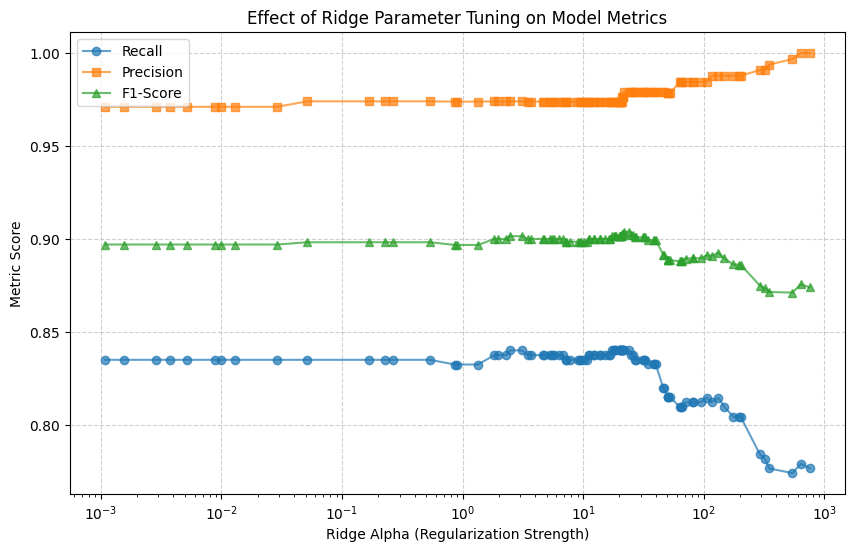

In [34]:
# Create a line plot to visualize the tuning effect
plt.figure(figsize=(10, 6))

plt.plot(df_results["alpha"], df_results["recall"], label="Recall", marker="o", alpha=0.7)
plt.plot(df_results["alpha"], df_results["precision"], label="Precision", marker="s", alpha=0.7)
plt.plot(df_results["alpha"], df_results["f1"], label="F1-Score", marker="^", alpha=0.7)
ax = plt.gca() 
ax.set_xscale('log')
plt.xlabel("Ridge Alpha (Regularization Strength)")
plt.ylabel("Metric Score")
plt.title("Effect of Ridge Parameter Tuning on Model Metrics")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


#### Lasso Logistic Regression

In [35]:
# We can only tune the C (float) and Class_weight to tryout balanced. 

In [36]:
def objective(trial):
    c = trial.suggest_float("C", 0.001, 1.0)
    class_weight = trial.suggest_categorical("Class_weight", ['balanced', None])
    
    model = LogisticRegression(
        penalty='l1', # Lasso
        class_weight=class_weight,
        C=c,
        solver='liblinear',
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='recall',
        n_jobs=-1,
    )
    recall = scores.mean()
    
    return recall


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15, n_jobs=-1)

lasso_unscaled_recall_optuna_results = study.trials_dataframe().sort_values("value", ascending=False)
top_5_lasso_unscaled_recall_optuna_results = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_lasso_unscaled_recall_optuna_results)

[I 2026-06-26 21:31:33,982] A new study created in memory with name: no-name-0aa14c14-dc17-4fe2-aed6-b034f38cba6e
[I 2026-06-26 21:31:34,033] Trial 0 finished with value: 0.8882505679974034 and parameters: {'C': 0.7570688532167243, 'Class_weight': None}. Best is trial 0 with value: 0.8882505679974034.
[I 2026-06-26 21:31:34,059] Trial 2 finished with value: 0.8958455047062641 and parameters: {'C': 0.9618544731081365, 'Class_weight': 'balanced'}. Best is trial 2 with value: 0.8958455047062641.
[I 2026-06-26 21:31:34,061] Trial 1 finished with value: 0.8857189224277832 and parameters: {'C': 0.695728360239207, 'Class_weight': None}. Best is trial 2 with value: 0.8958455047062641.
[I 2026-06-26 21:31:34,076] Trial 4 finished with value: 0.8857189224277832 and parameters: {'C': 0.4169175257372853, 'Class_weight': None}. Best is trial 2 with value: 0.8958455047062641.
[I 2026-06-26 21:31:34,090] Trial 5 finished with value: 0.8831872768581629 and parameters: {'C': 0.40816627603753874, 'Class

,number,value,datetime_start,datetime_complete,duration,params_C,params_Class_weight,state
2,2,0.895846,2026-06-26 21:31:33.987776,2026-06-26 21:31:34.059955,0 days 00:00:00.072179,0.961854,balanced,COMPLETE
6,6,0.895846,2026-06-26 21:31:33.993894,2026-06-26 21:31:34.090074,0 days 00:00:00.096180,0.946304,None,COMPLETE
10,10,0.895846,2026-06-26 21:31:34.000330,2026-06-26 21:31:34.090074,0 days 00:00:00.089744,0.984703,balanced,COMPLETE
14,14,0.893314,2026-06-26 21:31:34.005694,2026-06-26 21:31:34.090074,0 days 00:00:00.084380,0.838648,balanced,COMPLETE
13,13,0.890782,2026-06-26 21:31:34.004696,2026-06-26 21:31:34.090074,0 days 00:00:00.085378,0.814572,balanced,COMPLETE


In [37]:
def objective(trial):
    c = trial.suggest_float("C", 0.001, 1.0)
    class_weight = trial.suggest_categorical("Class_weight", ['balanced', None])
    
    model = LogisticRegression(
        penalty='l1', # Lasso
        class_weight=class_weight,
        C=c,
        solver='liblinear',
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='f1',
        n_jobs=-1,
    )
    recall = scores.mean()
    
    return recall


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

lasso_unscaled_f1_optuna_results = study.trials_dataframe().sort_values("value", ascending=False)
top_5_lasso_unscaled_f1_optuna_results = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_lasso_unscaled_f1_optuna_results)

[I 2026-06-26 21:31:34,113] A new study created in memory with name: no-name-e7378d37-ad67-48bd-8628-cdc230f59d3d
[I 2026-06-26 21:31:34,133] Trial 0 finished with value: 0.9222914050606503 and parameters: {'C': 0.19835438594546356, 'Class_weight': 'balanced'}. Best is trial 0 with value: 0.9222914050606503.
[I 2026-06-26 21:31:34,155] Trial 1 finished with value: 0.9236402061329537 and parameters: {'C': 0.26189339194433664, 'Class_weight': 'balanced'}. Best is trial 1 with value: 0.9236402061329537.
[I 2026-06-26 21:31:34,167] Trial 2 finished with value: 0.8855440396174007 and parameters: {'C': 0.026105764225927777, 'Class_weight': None}. Best is trial 1 with value: 0.9236402061329537.
[I 2026-06-26 21:31:34,180] Trial 3 finished with value: 0.9304212171893221 and parameters: {'C': 0.6227358245444966, 'Class_weight': 'balanced'}. Best is trial 3 with value: 0.9304212171893221.
[I 2026-06-26 21:31:34,192] Trial 4 finished with value: 0.931851680765481 and parameters: {'C': 0.522594900

,number,value,datetime_start,datetime_complete,duration,params_C,params_Class_weight,state
12,12,0.935037,2026-06-26 21:31:34.282551,2026-06-26 21:31:34.306763,0 days 00:00:00.024212,0.995448,balanced,COMPLETE
10,10,0.933644,2026-06-26 21:31:34.258285,2026-06-26 21:31:34.270431,0 days 00:00:00.012146,0.984159,balanced,COMPLETE
11,11,0.933644,2026-06-26 21:31:34.270431,2026-06-26 21:31:34.282551,0 days 00:00:00.012120,0.980480,balanced,COMPLETE
7,7,0.933469,2026-06-26 21:31:34.221804,2026-06-26 21:31:34.234056,0 days 00:00:00.012252,0.881094,balanced,COMPLETE
13,13,0.932037,2026-06-26 21:31:34.306763,2026-06-26 21:31:34.318921,0 days 00:00:00.012158,0.805961,balanced,COMPLETE


##### Tryout best params

In [38]:
lasso_recall_optimized_model = LogisticRegression(
    penalty='l1', # Lasso
    C=0.248927, 
    class_weight=None,
    solver='saga',
    random_state=random_state
)
lasso_recall_optimized_model.fit(X_train_scaled, y_train)
y_pred = lasso_recall_optimized_model.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Lasso Classifier (Recall Optimized)')

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


              precision    recall  f1-score   support

           0       0.94      0.99      0.97        99
           1       0.99      0.94      0.96        98

    accuracy                           0.96       197
   macro avg       0.97      0.96      0.96       197
weighted avg       0.97      0.96      0.96       197



In [39]:
lasso_f1_optimized_model = LogisticRegression(
    penalty='l1', # Lasso
    C=0.496023, 
    class_weight=None,
    solver='saga',
    random_state=random_state
)
lasso_f1_optimized_model.fit(X_train_scaled, y_train)
y_pred = lasso_f1_optimized_model.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Lasso Classifier (F1 Optimized)')

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


              precision    recall  f1-score   support

           0       0.95      0.99      0.97        99
           1       0.99      0.95      0.97        98

    accuracy                           0.97       197
   macro avg       0.97      0.97      0.97       197
weighted avg       0.97      0.97      0.97       197



[I 2026-06-26 21:31:34,484] A new study created in memory with name: no-name-78cdd970-9ace-47ee-ac5d-5dff7adac1e7
[I 2026-06-26 21:31:34,565] Trial 0 finished with value: 0.865465757870821 and parameters: {'C': 0.12756439274882828}. Best is trial 0 with value: 0.865465757870821.
[I 2026-06-26 21:31:34,588] Trial 2 finished with value: 0.8730606945796818 and parameters: {'C': 0.18248403535848934}. Best is trial 2 with value: 0.8730606945796818.
[I 2026-06-26 21:31:34,610] Trial 4 finished with value: 0.7969165855241804 and parameters: {'C': 0.008871256576262294}. Best is trial 2 with value: 0.8730606945796818.
[I 2026-06-26 21:31:34,612] Trial 5 finished with value: 0.8273937033430705 and parameters: {'C': 0.04336981415112653}. Best is trial 2 with value: 0.8730606945796818.
[I 2026-06-26 21:31:34,613] Trial 1 finished with value: 0.8882505679974034 and parameters: {'C': 0.5034274326108645}. Best is trial 1 with value: 0.8882505679974034.
[I 2026-06-26 21:31:34,637] Trial 3 finished wit

,number,Recall,datetime_start,datetime_complete,duration,C,F1-Score,Precision,state
90,90,0.898377,2026-06-26 21:31:35.275106,2026-06-26 21:31:35.404750,0 days 00:00:00.129644,0.993882,0.935037,0.975355,COMPLETE
92,92,0.898377,2026-06-26 21:31:35.285032,2026-06-26 21:31:35.404750,0 days 00:00:00.119718,0.996770,0.935037,0.975355,COMPLETE
98,98,0.898377,2026-06-26 21:31:35.348194,2026-06-26 21:31:35.415384,0 days 00:00:00.067190,0.995853,0.935037,0.975355,COMPLETE
29,29,0.895846,2026-06-26 21:31:34.682710,2026-06-26 21:31:34.841403,0 days 00:00:00.158693,0.973818,0.933644,0.975281,COMPLETE
91,91,0.895846,2026-06-26 21:31:35.276838,2026-06-26 21:31:35.404750,0 days 00:00:00.127912,0.975196,0.933644,0.975281,COMPLETE


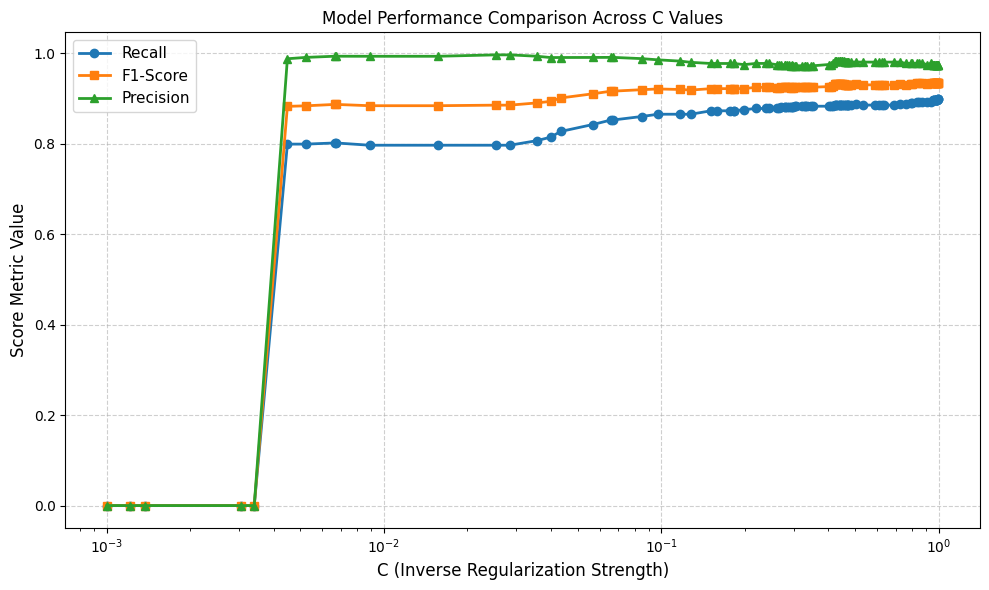

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

def objective(trial):
    c = trial.suggest_float("C", 0.001, 1, log=True)
    
    model = LogisticRegression(
        penalty='l1',
        class_weight='balanced',
        C=c,
        solver='liblinear',
        random_state=random_state # Ensure random_state is defined in your environment
    )
    
    # Evaluate multiple metrics simultaneously
    scoring_metrics = ['recall', 'f1', 'precision']
    cv_results = cross_validate(
        model, 
        X=X_train_scaled, # Ensure X_train_scaled is defined
        y=y_train,        # Ensure y_train is defined
        cv=cv,            # Ensure cv object is defined
        scoring=scoring_metrics, 
        n_jobs=-1
    )
    
    # Calculate mean scores
    mean_recall = cv_results['test_recall'].mean()
    mean_f1 = cv_results['test_f1'].mean()
    # FIXED: Key must match the 'test_<metric>' pattern from scoring_metrics
    mean_precision = cv_results['test_precision'].mean() 
    
    # Store additional metrics inside the trial attributes
    trial.set_user_attr("f1", mean_f1)
    trial.set_user_attr("precision", mean_precision)
    
    # Optuna still optimizes strictly based on recall
    return mean_recall

# Run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100, n_jobs=-1)

# Extract data including the user attributes
df_results = study.trials_dataframe()

# Clean up column names for easier plotting
df_results = df_results.rename(columns={
    'params_C': 'C',
    'value': 'Recall',
    'user_attrs_f1': 'F1-Score',
    'user_attrs_precision': 'Precision'
})

# Display Top 5 results sorted by Recall
top_5_results = df_results.sort_values("Recall", ascending=False).head(5)
display(top_5_results)

# Sort by C value to make line plotting continuous
df_plot = df_results.sort_values(by="C")

plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.set_xscale('log')
# Plot each metric against C
plt.plot(df_plot['C'], df_plot['Recall'], marker='o', label='Recall', linewidth=2)
plt.plot(df_plot['C'], df_plot['F1-Score'], marker='s', label='F1-Score', linewidth=2)
plt.plot(df_plot['C'], df_plot['Precision'], marker='^', label='Precision', linewidth=2)

# Formatting the visual aesthetics
plt.title('Model Performance Comparison Across C Values')
plt.xlabel('C (Inverse Regularization Strength)', fontsize=12)
plt.ylabel('Score Metric Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()


### Conclusions

In [41]:
pd.concat(classification_reports, keys=classification_report_keys)

precision    recall  \
Baseline Logistic Regression            0              0.958333  0.929293   
                                        1              0.930693  0.959184   
                                        accuracy       0.944162  0.944162   
                                        macro avg      0.944513  0.944238   
                                        weighted avg   0.944583  0.944162   
Baseline Ridge Classifier               0              0.890909  0.989899   
                                        1              0.988506  0.877551   
                                        accuracy       0.934010  0.934010   
                                        macro avg      0.939707  0.933725   
                                        weighted avg   0.939460  0.934010   
Baseline L1 (Lasso) Logistic Regression 0              0.949495  0.949495   
                                        1              0.948980  0.948980   
                                        accuracy       0.949239  0.949239   
                                        macro avg      0.949237  0.949237   
                                        weighted avg   0.949239  0.949239   
Logistic Regression (Recall Optimized)  0              0.950980  0.979798   
                                        1              0.978947  0.948980   
                                        accuracy       0.964467  0.964467   
                                        macro avg      0.964964  0.964389   
                                        weighted avg   0.964893  0.964467   
Logistic Regression (F1 Optimized)      0              0.950980  0.979798   
                                        1              0.978947  0.948980   
                                        accuracy       0.964467  0.964467   
                                        macro avg      0.964964  0.964389   
                                        weighted avg   0.964893  0.964467   
Ridge Classifier (Recall Optimized)     0              0.890909  0.989899   
                                        1              0.988506  0.877551   
                                        accuracy       0.934010  0.934010   
                                        macro avg      0.939707  0.933725   
                                        weighted avg   0.939460  0.934010   
Ridge Classifier (F1 Optimized)         0              0.890909  0.989899   
                                        1              0.988506  0.877551   
                                        accuracy       0.934010  0.934010   
                                        macro avg      0.939707  0.933725   
                                        weighted avg   0.939460  0.934010   
Lasso Classifier (Recall Optimized)     0              0.942308  0.989899   
                                        1              0.989247  0.938776   
                                        accuracy       0.964467  0.964467   
                                        macro avg      0.965778  0.964337   
                                        weighted avg   0.965658  0.964467   
Lasso Classifier (F1 Optimized)         0              0.951456  0.989899   
                                        1              0.989362  0.948980   
                                        accuracy       0.969543  0.969543   
                                        macro avg      0.970409  0.969439   
                                        weighted avg   0.970313  0.969543   

                                                      f1-score     support  
Baseline Logistic Regression            0             0.943590   99.000000  
                                        1             0.944724   98.000000  
                                        accuracy      0.944162    0.944162  
                                        macro avg     0.944157  197.000000  
                                        weighted avg  0.944154  197.000000  
Baseline Ridge Classifier               0        

The best model is the Lasso with macro avg precision 0.965778 recall 0.964337 and f1 0.964434. All models performed very well though on this dataset. Lasso could have been better than log reg due to multicollinearity

In [42]:
import numpy as np

pd.set_option('display.max_rows', None)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Ridge_Coef': ridge_f1_optimized_model.coef_,
})

# Sort features by the absolute size of their coefficients
coef_df['Abs_Coefficient'] = np.abs(coef_df['Ridge_Coef'])
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)
coef_df

,Feature,Ridge_Coef,Abs_Coefficient
7,V7,0.521043,0.521043
14,V14,-0.510886,0.510886
4,V4,0.446034,0.446034
1,V1,-0.331711,0.331711
10,V10,-0.212063,0.212063
18,V18,0.200497,0.200497
8,V8,-0.178609,0.178609
17,V17,-0.131455,0.131455
3,V3,-0.119278,0.119278
23,V23,-0.112265,0.112265


In [43]:
len(coef_df[coef_df['Abs_Coefficient'] == 0])

0

We can see 0 features coefs get shrunk to 0 by the Ridge model. All features must be at least slightly important

In [44]:
coefficients = lasso_f1_optimized_model.coef_[0]

# 3. Create a DataFrame to map features to their coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

# 4. VIEW RETAINED FEATURES (Coefficient is NOT 0)
selected_features = coef_df[coef_df['Coefficient'] != 0]
print("Features Selected by Lasso:")
print(selected_features)

# 5. VIEW REJECTED FEATURES (Coefficient is exactly 0)
dropped_features = coef_df[coef_df['Coefficient'] == 0]
print("\nFeatures Ignored by Lasso:")
print(dropped_features['Feature'].tolist())

Features Selected by Lasso:
   Feature  Coefficient
0     Time    -0.054337
3       V3    -0.004034
4       V4     2.157277
5       V5     0.137784
6       V6    -0.116894
8       V8    -0.891354
9       V9    -0.192883
10     V10    -1.167566
11     V11     0.474983
12     V12    -1.297026
13     V13    -0.316520
14     V14    -2.410177
18     V18     0.177864
20     V20    -0.201561
22     V22     0.410333
23     V23    -0.265760
25     V25    -0.033709
26     V26    -0.040076
27     V27    -0.242138
28     V28     0.277115
29  Amount     0.384781

Features Ignored by Lasso:
['V1', 'V2', 'V7', 'V15', 'V16', 'V17', 'V19', 'V21', 'V24']


We can see Lasso also removed 9 features during feature selection